 # **Science**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DIAGNOSIS FOR INJECTED SIGNAL
for (q,p) = (3, 5) on 11 sensors with 200 shots and 0.9 signal strength ε
Recovered peak from Bell measurement:  (q*, p*) = (3, 5)
Ground truth peak from Tr(D ρ_signal):   (q, p) = (3, 5)
Ground truth peak from Tr(D signal):     (q, p) = (3, 5)
----------------------------------------------------------------------
Peaks at `(q_0, p_0)` and `(-q_0, -p_0) mod d` in displacement map:
  At injected (q₀,p₀)          = (3,5): 0.23141420147967367570984720
  At symmetric (-q₀,-p₀) mod d = (8,6): 0.23141420147967367570984720
Final decision: (3, 5)
----------------------------------------------------------------------


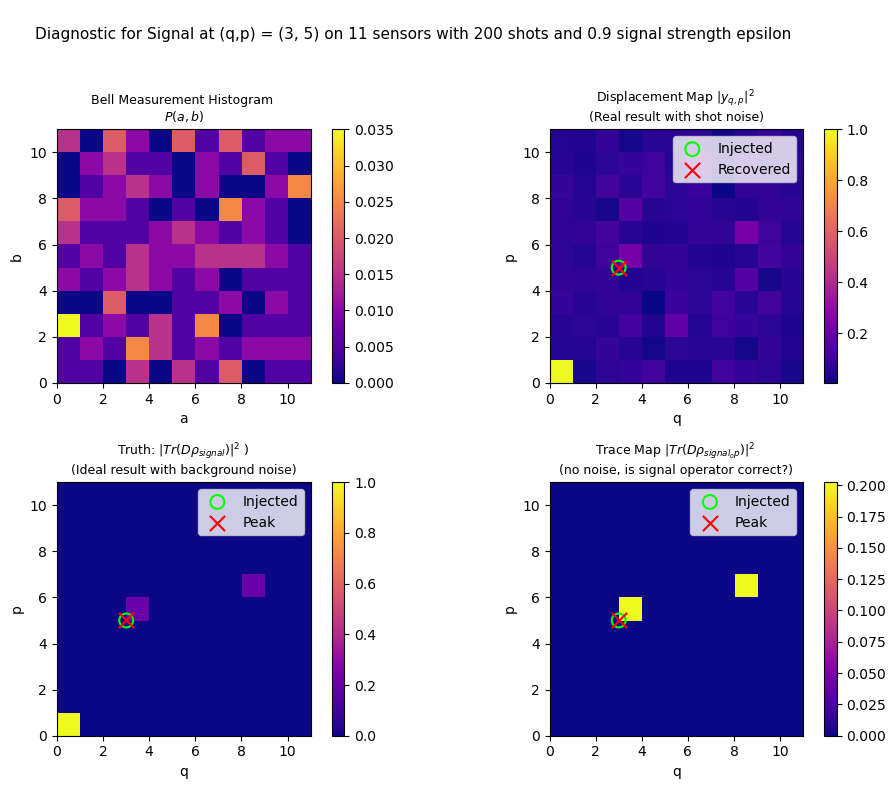

In [4]:
# @title Diagnosis for Bell Protocol

# (Displacement map of Bell Measurement on Conjugate Pairs)
import numpy as np
import matplotlib.pyplot as plt

import random
#seed_value = 42
#random.seed(seed_value)

# Quantum sensor array for photon localization in phase space (creates states and displacement operators)
class QuantumSensorArray:
    def __init__(self, n_sensors, array_length=1.0):
        self.n_sensors = n_sensors
        self.L = array_length
        self.dim = n_sensors  # Hilbert space dimension

    # Constructs the Heisenberg-Weyl displacement operator D_{q,p} = τ^{qp} Z^p X^q
    def get_displacement_operator(self, q_idx, p_idx):
        d = self.dim
        omega = np.exp(2j * np.pi / d)
        Z = np.diag([omega ** j for j in range(d)])
        X = np.roll(np.eye(d), 1, axis=0)
        tau = np.exp(np.pi * 1j * (d + 1) / d)
        D_qp = tau ** (q_idx * p_idx) * np.linalg.matrix_power(Z, p_idx) @ np.linalg.matrix_power(X, q_idx)
        return D_qp

# Constructs Bell basis |Φ_{a,b}> which is eigenbasis for D_{q,p} ⊗ D_{-q,p}. |Φ_{a,b}> = (1/√d) Σ_j exp(2πi*b*j/d) |j+a> ⊗ |-j>
def construct_bell_basis(sensor_array):
    d = sensor_array.dim
    bell_states = []
    for a in range(d):
        for b in range(d):
            state = np.zeros(d * d, dtype=complex)
            for j in range(d):
                phase = np.exp(2j * np.pi * b * j / d)
                ket1_idx = (j + a) % d
                ket2_idx = (-j + d) % d  # Use +d to ensure positive result before modulo
                final_idx = ket1_idx * d + ket2_idx
                state[final_idx] += phase
            state /= np.sqrt(d) # Normalize
            bell_states.append(state)
    return np.array(bell_states).T

# Simulates measurements of rho_tensor in Bell basis with projectors (outer product): bell_state @ bell_state.conj().T
def simulate_bell_measurements(rho_tensor, d, sensor_array, n_shots=1000):
    bell_basis = construct_bell_basis(sensor_array)
    projectors = []
    for i in range(d * d):
        bell_state = bell_basis[:, i:i+1]
        projector = bell_state @ bell_state.conj().T
        projectors.append(projector)

    # Theoretical probabilities calculated inside simulate_bell_measurements according to Born rule: $p_{a,b} = \text{Tr}[\Pi_{a,b} (\rho \otimes \rho^*)]$
    probs = [np.real(np.trace(p @ rho_tensor)) for p in projectors]
    probs = np.maximum(0, probs)
    probs /= np.sum(probs)

    outcomes = np.random.choice(d * d, size=n_shots, p=probs)
    a_vals = outcomes // d
    b_vals = outcomes % d
    return a_vals, b_vals

# Fourier kernel (character) $e^{i \frac{2\pi}{d} (a p - b q)}$</font> = $\chi_{q,p}(a,b)$
# to reconstruct displacement map |y_{q,p}|^2 from Bell measurement outcomes p_{a,b}
# Estimator v_qp is for y_{q,p}^2. The map shows |v_qp| which is |y_{q,p}|^2
def compute_displacement_map(p_ab, d):
    v_qp = np.zeros((d, d), dtype=complex)
    a_coords = np.arange(d)
    b_coords = np.arange(d)

    for q in range(d):
        for p in range(d):
            phase_grid = np.exp(2j * np.pi * (a_coords[:, np.newaxis] * p - b_coords * q) / d)
            v_qp[q, p] = np.sum(p_ab * phase_grid)

    return np.abs(v_qp)

# Special: Computes 'ground truth' displacement map |y_{q,p}|^2 by directly calculating y_{q,p} = Tr(D_{q,p} ρ)
def compute_yqp_via_trace(rho, sensor_array):
    d = sensor_array.dim
    y_qp = np.zeros((d, d), dtype=complex)
    for q in range(d):
        for p in range(d):
            D = sensor_array.get_displacement_operator(q, p)
            y_qp[q, p] = np.trace(D @ rho)
    return np.abs(y_qp) ** 2

# Runs test for a given signal displacement (q_0, p_0).
def test_bell_on_pure_signal(sensor_array, q_0, p_0, epsilon=0.4, n_shots=1000):
    d = sensor_array.dim

    # Step 1: Construct unknown signal state ρ_signal: To create a signal peak at (q₀,p₀) in the displacement basis,
    # the state ρ = (1/d)(I + ε * signal_op) is constructed, where signal_op is Hermitian.
    D_qp_0 = sensor_array.get_displacement_operator(q_0, p_0)
    signal_operator = 0.5 * (D_qp_0.conj().T + D_qp_0)  # The signal is on the D† component of Bloch decomposition
    rho_signal = (1/d) * (np.eye(d) + epsilon * signal_operator)

    # The "pure signal" is the part of the state deviating from the identity.
    pure_signal_density = (epsilon / d) * signal_operator

    # Step 2: Construct the conjugate pair ρ ⊗ ρ* for measurement
    rho_tensor = np.kron(rho_signal, np.conjugate(rho_signal))

    # Step 3: Simulate Bell measurements on the prepared rho_tensor
    a_vals, b_vals = simulate_bell_measurements(rho_tensor, d, sensor_array, n_shots=n_shots)


    # Step 4: Create the Bell outcome histogram from the measurement samples
    p_ab, _, _ = np.histogram2d(a_vals, b_vals, bins=d, range=[[0, d], [0, d]])
    if np.sum(p_ab) > 0:
        p_ab /= np.sum(p_ab)

    # Step 5: Reconstruct the displacement map from the histogram
    displacement_map = compute_displacement_map(p_ab, d)
    q_star, p_star = np.unravel_index(np.argmax(displacement_map), displacement_map.shape)

    # Step 6: Compute ground truth maps for comparison
    trace_map = compute_yqp_via_trace(rho_signal, sensor_array)
    trace_map_signal = compute_yqp_via_trace(pure_signal_density, sensor_array)
    true_qp_from_trace = np.unravel_index(np.argmax(trace_map), trace_map.shape)
    signal_peak = np.unravel_index(np.argmax(trace_map_signal), trace_map_signal.shape)



    # SPECIAL: Find peaks while ignoring the (0,0) artifact
    # Make a copy to not alter the plot
    displacement_map_for_peak_finding = displacement_map.copy()
    trace_map_for_peak_finding = trace_map.copy()
    # Set the (0,0) element to 0 so it's not picked by argmax
    displacement_map_for_peak_finding[0, 0] = 0
    trace_map_for_peak_finding[0, 0] = 0
    # Find the argmax on the modified maps
    q_star, p_star = np.unravel_index(np.argmax(displacement_map_for_peak_finding), displacement_map.shape)
    true_qp_from_trace = np.unravel_index(np.argmax(trace_map_for_peak_finding), trace_map.shape)


    # Print Diagnostics
    print("="*70)
    print(f"DIAGNOSIS FOR INJECTED SIGNAL")
    print(f"for (q,p) = ({q_0}, {p_0}) on {d} sensors with {n_shots} shots and {epsilon} signal strength ε")
    print("="*70)
    print(f"Recovered peak from Bell measurement:  (q*, p*) = ({q_star}, {p_star})")
    print(f"Ground truth peak from Tr(D ρ_signal):   (q, p) = ({int(true_qp_from_trace[0])}, {int(true_qp_from_trace[1])})")
    print(f"Ground truth peak from Tr(D signal):     (q, p) = ({int(signal_peak[0])}, {int(signal_peak[1])})")
    print("-" * 70)

    # Analyze which peak is stronger in the displacement map
    q_neg = (-q_0) % d
    p_neg = (-p_0) % d
    peak1_height = displacement_map[q_0, p_0]
    peak2_height = displacement_map[q_neg, p_neg]
    print(f"Peaks at `(q_0, p_0)` and `(-q_0, -p_0) mod d` in displacement map:")
    print(f"  At injected (q₀,p₀)          = ({q_0},{p_0}): {peak1_height:.26f}")
    print(f"  At symmetric (-q₀,-p₀) mod d = ({q_neg},{p_neg}): {peak2_height:.26f}")
    print(f"Final decision: ({q_star}, {p_star})")
    # Decision based on which peak is higher after Fourier reconstruction,
    # which depends on accumulated shot noise across all measurements.
    print("-" * 70)


    ######## Diagnostic: Manually compute all p_{a,b} = ⟨Φ_{a,b}|ρ⊗ρ*|Φ_{a,b}⟩
    bell_basis = construct_bell_basis(sensor_array)
    bell_probs = []
    for idx in range(d * d):
        phi_ab = bell_basis[:, idx]
        prob = np.real(phi_ab.conj().T @ rho_tensor @ phi_ab)
        bell_probs.append((idx // d, idx % d, prob))  # (a, b, p_{a,b})

    # Sort by descending probability
    bell_probs.sort(key=lambda x: x[2], reverse=True)

    ####### rank probabilities
    #print("Top Bell measurement probabilities")
    #for rank, (a, b, prob) in enumerate(bell_probs[:5]):
    #    print(f"Rank {rank+1}: (a,b) = ({a},{b}), p = {prob:.6f}")
    #print("-" * 70)

    # Visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f'\nDiagnostic for Signal at (q,p) = ({q_0}, {p_0}) on {d} sensors with {n_shots} shots and {epsilon} signal strength epsilon', fontsize=11)

    im1 = ax1.imshow(p_ab.T, origin='lower', cmap='plasma', extent=[0,d,0,d])
    ax1.set_title("Bell Measurement Histogram \n$P(a,b)$", fontsize=9)
    ax1.set_xlabel("a")
    ax1.set_ylabel("b")
    fig.colorbar(im1, ax=ax1)

    im2 = ax2.imshow(displacement_map.T, origin='lower', cmap='plasma', extent=[0,d,0,d])
    ax2.scatter(q_0, p_0, s=100, facecolors='none', edgecolors='lime', linewidths=1.5, label='Injected')
    ax2.scatter(q_star, p_star, color='red', s=120, marker='x', label='Recovered')
    ax2.set_title("Displacement Map $|y_{q,p}|^2$ \n(Real result with shot noise)", fontsize=9)
    ax2.set_xlabel("q")
    ax2.set_ylabel("p")
    ax2.legend()
    fig.colorbar(im2, ax=ax2)

    im3 = ax3.imshow(trace_map.T, origin='lower', cmap='plasma', extent=[0,d,0,d])
    ax3.scatter(q_0, p_0, s=100, facecolors='none', edgecolors='lime', linewidths=1.5, label='Injected')
    ax3.scatter(true_qp_from_trace[0], true_qp_from_trace[1], color='red', s=120, marker='x', label='Peak')
    ax3.set_title("Truth: $|Tr(D \\rho_{signal})|^2$ ) \n(Ideal result with background noise)", fontsize=9)
    ax3.set_xlabel("q")
    ax3.set_ylabel("p")
    ax3.legend()
    fig.colorbar(im3, ax=ax3)

    im4 = ax4.imshow(trace_map_signal.T, origin='lower', cmap='plasma', extent=[0,d,0,d])
    ax4.scatter(q_0, p_0, s=100, facecolors='none', edgecolors='lime', linewidths=1.5, label='Injected')
    ax4.scatter(signal_peak[0], signal_peak[1], color='red', s=120, marker='x', label='Peak')
    ax4.set_title("Trace Map $|Tr(D \\rho_{signal_op})|^2$ \n(no noise, is signal operator correct?)", fontsize=9)
    ax4.set_xlabel("q")
    ax4.set_ylabel("p")
    ax4.legend()
    fig.colorbar(im4, ax=ax4)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# EXECUTION
d = 11
sensor_array = QuantumSensorArray(n_sensors=d)
q_0 = 3
p_0 = 5
result = test_bell_on_pure_signal(sensor_array, q_0, p_0, epsilon=0.9, n_shots=200)

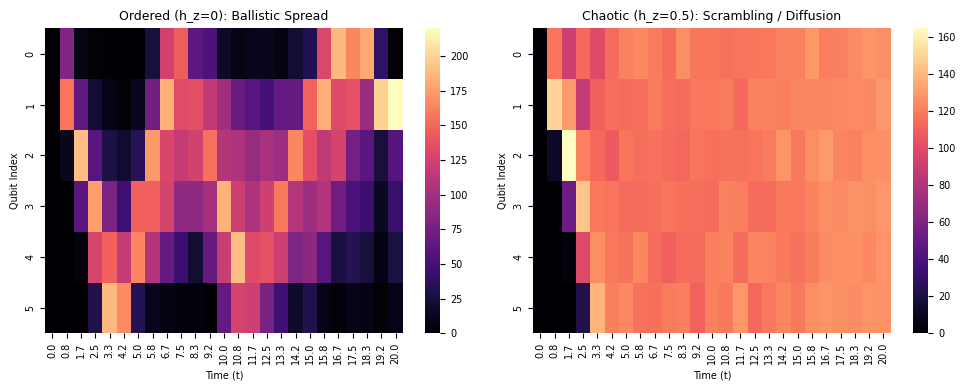

In [5]:
# @title OTOC: Light Cone of Scrambling

!pip install cirq cirq-ionq -q
# ⚠️ Optional: Restart kernel
import cirq_ionq # https://docs.ionq.com/sdks/cirq
import cirq      # https://quantumai.google/cirq/hardware/ionq/circuits

# OTOC for all qubits over time. Ordered vs Chaotic
from scipy.linalg import norm

def get_unitary_from_circuit(qubits, t, h_x, h_z, steps=25):
    """
    Creates the Unitary Matrix U(t) for a specific Hamiltonian setup.
    H = Sum(Zi Zj) + h_x * Sum(Xi) + h_z * Sum(Zi)
    """
    circuit = cirq.Circuit()
    dt = t / steps
    n = len(qubits)

    for _ in range(steps):
        # 1. Interaction (ZZ) - The "Scrambler"
        for i in range(n - 1):
            circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))
            circuit.append(cirq.rz(rads=2 * dt).on(qubits[i+1]))
            circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))

        # 2. Transverse Field (X) - The "Driver"
        if h_x != 0:
            for i in range(n):
                circuit.append(cirq.rx(rads=2 * h_x * dt).on(qubits[i]))

        # 3. Longitudinal Field (Z) - The "Chaos Generator"
        # Adding this term breaks integrability and causes chaos.
        if h_z != 0:
            for i in range(n):
                circuit.append(cirq.rz(rads=2 * h_z * dt).on(qubits[i]))

    # Extract the full unitary matrix (2^N x 2^N)
    return cirq.unitary(circuit)

def calculate_otoc_heatmap(num_qubits, h_x, h_z, t_max, t_steps):
    """
    Calculates OTOC for all qubits over time to visualize the Light Cone.
    """
    qubits = cirq.LineQubit.range(num_qubits)
    times = np.linspace(0, t_max, t_steps)
    # Matrix to store results: Rows = Qubits, Cols = Time
    heatmap_data = np.zeros((num_qubits, t_steps))

    # V is always X on the first qubit (The "Butterfly")
    op_list_V = [np.eye(2)] * num_qubits
    op_list_V[0] = np.array([[0, 1], [1, 0]]) # Pauli X
    V = op_list_V[0]
    for i in range(1, num_qubits):
        V = np.kron(V, op_list_V[i])

    #print(f"Generating Heatmap (h_z={h_z})...")

    for t_idx, t in enumerate(times):
        if t == 0: continue

        # Get the global Unitary for this time point
        U = get_unitary_from_circuit(qubits, t, h_x, h_z) # Using previous function
        U_dag = U.conj().T

        # Calculate OTOC for each qubit j as the "Probe"
        for j in range(num_qubits):
            # W is Z on qubit j
            op_list_W = [np.eye(2)] * num_qubits
            op_list_W[j] = np.array([[1, 0], [0, -1]]) # Pauli Z

            # Construct W matrix
            W = op_list_W[0]
            for k in range(1, num_qubits):
                W = np.kron(W, op_list_W[k])

            # Heisenberg evolution: W(t) = U^dag * W * U
            W_t = U_dag @ W @ U

            # Commutator magnitude
            commutator = W_t @ V - V @ W_t
            heatmap_data[j, t_idx] = np.linalg.norm(commutator) ** 2

    return times, heatmap_data

# --- Execution ---
n_qubits = 6 # Kept small for simulation speed
t_max = 20.0
t_steps = 25

# Generate data for Chaotic vs Ordered
_, data_ordered = calculate_otoc_heatmap(n_qubits, 1.0, 0.0, t_max, t_steps)
times, data_chaotic = calculate_otoc_heatmap(n_qubits, 1.0, 0.5, t_max, t_steps)

# --- Plotting ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Define your desired font size
small_size = 7

# Plot 1
sns.heatmap(data_ordered, ax=ax1, cmap='magma', xticklabels=np.round(times, 1))
ax1.set_title("Ordered (h_z=0): Ballistic Spread", fontsize=small_size + 2)
ax1.set_xlabel("Time (t)", fontsize=small_size)
ax1.set_ylabel("Qubit Index", fontsize=small_size)
ax1.tick_params(axis='both', labelsize=small_size)

# Adjust Colorbar 1
cbar1 = ax1.collections[0].colorbar
cbar1.ax.tick_params(labelsize=small_size)

# Plot 2
sns.heatmap(data_chaotic, ax=ax2, cmap='magma', xticklabels=np.round(times, 1))
ax2.set_title("Chaotic (h_z=0.5): Scrambling / Diffusion", fontsize=small_size + 2)
ax2.set_xlabel("Time (t)", fontsize=small_size)
ax2.set_ylabel("Qubit Index", fontsize=small_size)
ax2.tick_params(axis='both', labelsize=small_size)

# Adjust Colorbar 2
cbar2 = ax2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=small_size)

plt.tight_layout()
plt.show()